# 06 — Robot Robustness Analysis

Bu notebook iki stratejiyi karşılaştırır:

- **Baseline:** 2.0 ATR initial stop, 2.5 ATR trailing, %6 activation
- **Candidate:** 1.5 ATR initial stop, 2.5 ATR trailing, %6 activation

Amaç yeni bir optimum bulmak değil; Candidate sonucunun:

- dönemler arasında,
- daha yüksek işlem maliyetlerinde,
- yakın parametre değerlerinde

dayanıklı kalıp kalmadığını kontrol etmektir.


In [1]:
from pathlib import Path
from dataclasses import replace
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.config import StrategyConfig, PortfolioConfig
from src.features import add_indicators
from src.signals import build_market_regime
from src.experiments import (
    evaluate_strategy,
    run_strategy_grid,
)
from src.metrics import yearly_performance

sns.set_theme(style="whitegrid")


c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Verileri ve özellikleri hazırla


In [2]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(market_features)

LAST_DATE = stock_features["Date"].max().strftime("%Y-%m-%d")

PERIODS = {
    "Development": ("2018-01-01", "2022-12-31"),
    "Validation": ("2023-01-01", "2024-12-31"),
    "Holdout": ("2025-01-01", LAST_DATE),
    "Full": ("2018-01-01", LAST_DATE),
}

base_portfolio = PortfolioConfig()

baseline_strategy = StrategyConfig(
    buy_score=12,
    minimum_adx=18.0,
    volume_multiplier=1.3,
    initial_stop_atr=2.0,
    trailing_stop_atr=2.5,
    trailing_activation_return=0.06,
)

candidate_strategy = replace(
    baseline_strategy,
    initial_stop_atr=1.5,
)


## 2. Baseline ve Candidate dönem karşılaştırması

Holdout burada yalnızca son kontrol için kullanılır. Bu aşamadan sonra holdout dönemi tamamen tüketilmiş kabul edilmelidir.


In [3]:
strategy_map = {
    "Baseline": baseline_strategy,
    "Candidate_1_5_ATR": candidate_strategy,
}

comparison_records = []
stored_outputs = {}

for strategy_name, strategy_config in strategy_map.items():
    for period_name, (start, end) in PERIODS.items():
        metrics, equity_df, trades_df = evaluate_strategy(
            stock_features=stock_features,
            market_regime=market_regime,
            strategy_config=strategy_config,
            portfolio_config=base_portfolio,
            start=start,
            end=end,
        )

        metrics["Strategy_Name"] = strategy_name
        metrics["Period_Name"] = period_name
        comparison_records.append(metrics)

        stored_outputs[(strategy_name, period_name)] = {
            "equity": equity_df,
            "trades": trades_df,
        }

strategy_period_comparison = pd.DataFrame(comparison_records)

comparison_columns = [
    "Strategy_Name",
    "Period_Name",
    "CAGR_%",
    "Max_Drawdown_%",
    "Profit_Factor",
    "Win_Rate_%",
    "Sharpe",
    "Calmar",
    "Trade_Count",
]

display(
    strategy_period_comparison[comparison_columns]
    .sort_values(["Period_Name", "Strategy_Name"])
)


,Strategy_Name,Period_Name,CAGR_%,Max_Drawdown_%,Profit_Factor,Win_Rate_%,Sharpe,Calmar,Trade_Count
0,Baseline,Development,60.984835,-21.036353,2.639109,42.929293,2.580370,2.899021,396
4,Candidate_1_5_ATR,Development,74.470932,-29.700609,2.561045,38.528139,2.497274,2.507387,462
3,Baseline,Full,48.590787,-21.036353,2.157551,39.540816,2.165601,2.309848,784
7,Candidate_1_5_ATR,Full,61.512798,-29.700609,2.048824,33.751306,2.139043,2.071095,957
2,Baseline,Holdout,43.890732,-17.296093,1.882969,36.065574,1.978071,2.537610,183
6,Candidate_1_5_ATR,Holdout,49.742071,-19.848520,1.658449,29.795918,1.798741,2.506085,245
1,Baseline,Validation,27.310294,-18.310984,1.626837,36.744186,1.385437,1.491471,215
5,Candidate_1_5_ATR,Validation,36.286483,-27.366465,1.545097,27.737226,1.410449,1.325947,274


## 3. Candidate'ın baseline'a göre farkı


In [4]:
period_pivot = strategy_period_comparison.pivot_table(
    index="Period_Name",
    columns="Strategy_Name",
    values=[
        "CAGR_%",
        "Max_Drawdown_%",
        "Profit_Factor",
        "Sharpe",
        "Calmar",
        "Trade_Count",
    ],
    aggfunc="first",
)

difference_rows = []

for period_name in period_pivot.index:
    difference_rows.append({
        "Period_Name": period_name,
        "CAGR_Difference_pp": (
            period_pivot.loc[
                period_name,
                ("CAGR_%", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("CAGR_%", "Baseline"),
            ]
        ),
        "Drawdown_Difference_pp": (
            period_pivot.loc[
                period_name,
                ("Max_Drawdown_%", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("Max_Drawdown_%", "Baseline"),
            ]
        ),
        "Profit_Factor_Difference": (
            period_pivot.loc[
                period_name,
                ("Profit_Factor", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("Profit_Factor", "Baseline"),
            ]
        ),
        "Sharpe_Difference": (
            period_pivot.loc[
                period_name,
                ("Sharpe", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("Sharpe", "Baseline"),
            ]
        ),
        "Calmar_Difference": (
            period_pivot.loc[
                period_name,
                ("Calmar", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("Calmar", "Baseline"),
            ]
        ),
        "Extra_Trades": (
            period_pivot.loc[
                period_name,
                ("Trade_Count", "Candidate_1_5_ATR"),
            ]
            - period_pivot.loc[
                period_name,
                ("Trade_Count", "Baseline"),
            ]
        ),
    })

strategy_difference = pd.DataFrame(difference_rows)

display(strategy_difference)


,Period_Name,CAGR_Difference_pp,Drawdown_Difference_pp,Profit_Factor_Difference,Sharpe_Difference,Calmar_Difference,Extra_Trades
0,Development,13.486097,-8.664256,-0.078064,-0.083095,-0.391634,66
1,Full,12.922011,-8.664256,-0.108727,-0.026558,-0.238753,173
2,Holdout,5.851339,-2.552426,-0.224520,-0.179330,-0.031525,62
3,Validation,8.976189,-9.055482,-0.081739,0.025011,-0.165524,59


## 4. Yıllık performans karşılaştırması


In [5]:
yearly_frames = []

for strategy_name in strategy_map:
    full_equity = stored_outputs[(strategy_name, "Full")]["equity"]
    yearly = yearly_performance(full_equity)
    yearly["Strategy_Name"] = strategy_name
    yearly_frames.append(yearly)

yearly_comparison = pd.concat(
    yearly_frames,
    ignore_index=True,
)

display(
    yearly_comparison.sort_values(
        ["Year", "Strategy_Name"]
    )
)


,Year,Start_Equity,End_Equity,Return_%,Yearly_Max_DD_%,Strategy_Name
0,2018,5.000000e+05,4.891342e+05,-2.173156,-2.173156,Baseline
9,2018,5.000000e+05,4.888084e+05,-2.238312,-2.238312,Candidate_1_5_ATR
1,2019,4.891342e+05,6.532903e+05,33.560547,-13.507729,Baseline
10,2019,4.888084e+05,5.746467e+05,17.560716,-18.195607,Candidate_1_5_ATR
2,2020,6.566575e+05,1.190814e+06,81.344826,-15.048109,Baseline
11,2020,5.760335e+05,1.289552e+06,123.867475,-16.322689,Candidate_1_5_ATR
3,2021,1.198087e+06,1.428009e+06,19.190745,-21.036353,Baseline
12,2021,1.303478e+06,1.426700e+06,9.453302,-29.700609,Candidate_1_5_ATR
4,2022,1.438841e+06,3.703904e+06,157.422722,-8.422485,Baseline
13,2022,1.440903e+06,5.195605e+06,260.579726,-11.217900,Candidate_1_5_ATR


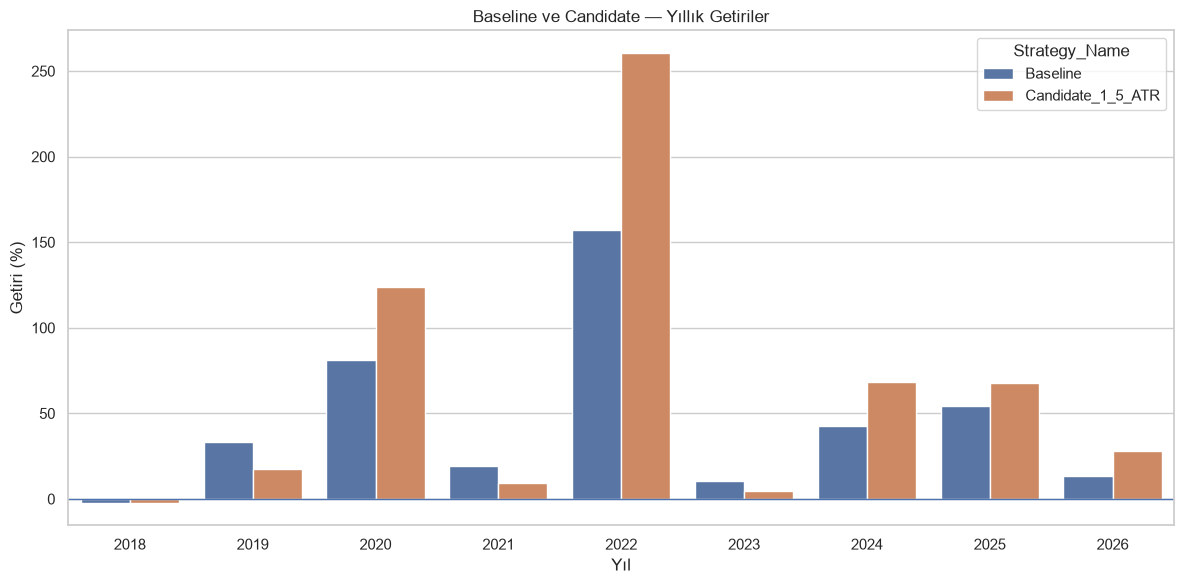

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=yearly_comparison,
    x="Year",
    y="Return_%",
    hue="Strategy_Name",
)

plt.axhline(0, linewidth=1)
plt.title("Baseline ve Candidate — Yıllık Getiriler")
plt.xlabel("Yıl")
plt.ylabel("Getiri (%)")
plt.tight_layout()
plt.show()


## 5. İşlem maliyeti hassasiyeti

Candidate daha fazla işlem ürettiği için daha yüksek maliyetlerde avantajını koruması gerekir.

Senaryolar:

- Normal: %0,20 komisyon + %0,20 slippage
- Yüksek: %0,30 + %0,30
- Stres: %0,40 + %0,40


In [7]:
cost_scenarios = {
    "Normal_0_2": (0.002, 0.002),
    "High_0_3": (0.003, 0.003),
    "Stress_0_4": (0.004, 0.004),
}

cost_records = []

for strategy_name, strategy_config in strategy_map.items():
    for scenario_name, (
        commission_rate,
        slippage_rate,
    ) in cost_scenarios.items():
        stressed_portfolio = replace(
            base_portfolio,
            commission_rate=commission_rate,
            slippage_rate=slippage_rate,
        )

        for period_name in ["Validation", "Holdout"]:
            start, end = PERIODS[period_name]

            metrics, _, _ = evaluate_strategy(
                stock_features=stock_features,
                market_regime=market_regime,
                strategy_config=strategy_config,
                portfolio_config=stressed_portfolio,
                start=start,
                end=end,
            )

            metrics.update({
                "Strategy_Name": strategy_name,
                "Scenario_Name": scenario_name,
                "Period_Name": period_name,
                "Commission": commission_rate,
                "Slippage": slippage_rate,
            })

            cost_records.append(metrics)

cost_sensitivity = pd.DataFrame(cost_records)

display(
    cost_sensitivity[
        [
            "Strategy_Name",
            "Scenario_Name",
            "Period_Name",
            "CAGR_%",
            "Max_Drawdown_%",
            "Profit_Factor",
            "Sharpe",
            "Calmar",
            "Trade_Count",
        ]
    ].sort_values(
        [
            "Period_Name",
            "Scenario_Name",
            "Strategy_Name",
        ]
    )
)


,Strategy_Name,Scenario_Name,Period_Name,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count
3,Baseline,High_0_3,Holdout,33.884524,-17.737864,1.656267,1.622321,1.910293,189
9,Candidate_1_5_ATR,High_0_3,Holdout,32.613992,-20.834659,1.454366,1.330637,1.565372,245
1,Baseline,Normal_0_2,Holdout,43.890732,-17.296093,1.882969,1.978071,2.537610,183
7,Candidate_1_5_ATR,Normal_0_2,Holdout,49.742071,-19.848520,1.658449,1.798741,2.506085,245
5,Baseline,Stress_0_4,Holdout,32.727028,-17.466588,1.627833,1.641950,1.873693,190
11,Candidate_1_5_ATR,Stress_0_4,Holdout,20.104278,-22.099725,1.320757,0.922702,0.909707,245
2,Baseline,High_0_3,Validation,23.036431,-20.410800,1.531682,1.223443,1.128639,218
8,Candidate_1_5_ATR,High_0_3,Validation,27.595818,-29.172680,1.453369,1.156467,0.945947,275
0,Baseline,Normal_0_2,Validation,27.310294,-18.310984,1.626837,1.385437,1.491471,215
6,Candidate_1_5_ATR,Normal_0_2,Validation,36.286483,-27.366465,1.545097,1.410449,1.325947,274


## 6. Candidate çevresinde parametre platosu

Burada yeni bir kazanan seçmiyoruz. 1.5 ATR sonucunun tek bir keskin noktaya mı bağlı olduğunu, yoksa yakın parametrelerin de benzer performans üretip üretmediğini kontrol ediyoruz.


In [8]:
neighborhood_grid = {
    "initial_stop_atr": [1.25, 1.50, 1.75],
    "trailing_stop_atr": [2.25, 2.50, 2.75],
    "trailing_activation_return": [0.05, 0.06, 0.07],
}

neighborhood_development = run_strategy_grid(
    stock_features=stock_features,
    market_regime=market_regime,
    base_strategy=baseline_strategy,
    portfolio_config=base_portfolio,
    parameter_grid=neighborhood_grid,
    start=PERIODS["Development"][0],
    end=PERIODS["Development"][1],
)

neighborhood_validation = run_strategy_grid(
    stock_features=stock_features,
    market_regime=market_regime,
    base_strategy=baseline_strategy,
    portfolio_config=base_portfolio,
    parameter_grid=neighborhood_grid,
    start=PERIODS["Validation"][0],
    end=PERIODS["Validation"][1],
)

parameter_columns = [
    "Strategy_initial_stop_atr",
    "Strategy_trailing_stop_atr",
    "Strategy_trailing_activation_return",
]

neighborhood_merged = neighborhood_development.merge(
    neighborhood_validation,
    on=parameter_columns,
    suffixes=("_Development", "_Validation"),
)

neighborhood_merged["Robust_Calmar"] = neighborhood_merged[
    ["Calmar_Development", "Calmar_Validation"]
].min(axis=1)

neighborhood_merged["Robust_PF"] = neighborhood_merged[
    [
        "Profit_Factor_Development",
        "Profit_Factor_Validation",
    ]
].min(axis=1)

neighborhood_merged["CAGR_Gap"] = (
    neighborhood_merged["CAGR_%_Development"]
    - neighborhood_merged["CAGR_%_Validation"]
).abs()

neighborhood_view = neighborhood_merged.sort_values(
    ["Robust_Calmar", "Robust_PF", "CAGR_Gap"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(
    neighborhood_view[
        parameter_columns
        + [
            "CAGR_%_Development",
            "CAGR_%_Validation",
            "Max_Drawdown_%_Development",
            "Max_Drawdown_%_Validation",
            "Profit_Factor_Development",
            "Profit_Factor_Validation",
            "Calmar_Development",
            "Calmar_Validation",
            "Robust_Calmar",
            "Robust_PF",
            "CAGR_Gap",
        ]
    ].head(15)
)


Strateji grid: 2023-01-01 → 2024-12-31: 100%|██████████| 27/27 [02:02<00:00,  4.52s/it]


,Strategy_initial_stop_atr,Strategy_trailing_stop_atr,Strategy_trailing_activation_return,CAGR_%_Development,CAGR_%_Validation,Max_Drawdown_%_Development,Max_Drawdown_%_Validation,Profit_Factor_Development,Profit_Factor_Validation,Calmar_Development,Calmar_Validation,Robust_Calmar,Robust_PF,CAGR_Gap
0,1.50,2.50,0.05,75.941528,42.846095,-28.346348,-24.118494,2.589836,1.639279,2.679059,1.776483,1.776483,1.639279,33.095433
1,1.50,2.25,0.07,63.722923,40.482543,-26.771625,-23.486375,2.207857,1.654613,2.380241,1.723661,1.723661,1.654613,23.240380
2,1.75,2.50,0.06,68.874887,32.923003,-25.702778,-20.961727,2.652255,1.661181,2.679667,1.570625,1.570625,1.661181,35.951883
3,1.25,2.25,0.05,83.293592,41.139442,-30.337501,-26.551979,2.338699,1.524067,2.745565,1.549393,1.549393,1.524067,42.154150
4,1.75,2.50,0.05,59.102196,32.404601,-28.389140,-20.961727,2.381832,1.643379,2.081859,1.545894,1.545894,1.643379,26.697595
5,1.75,2.25,0.05,58.888242,29.880928,-28.628644,-20.706876,2.272809,1.576864,2.056969,1.443044,1.443044,1.576864,29.007314
6,1.50,2.25,0.06,54.529620,33.528837,-29.354131,-24.118494,2.041678,1.530444,1.857647,1.390171,1.390171,1.530444,21.000784
7,1.75,2.50,0.07,69.602845,28.811277,-26.118868,-20.849430,2.656780,1.559243,2.664849,1.381874,1.381874,1.559243,40.791569
8,1.75,2.25,0.06,63.279243,28.670119,-28.171771,-20.961727,2.399609,1.548946,2.246193,1.367736,1.367736,1.548946,34.609123
9,1.25,2.25,0.07,83.707638,35.821779,-26.769038,-26.482747,2.414735,1.520201,3.127032,1.352646,1.352646,1.520201,47.885859


In [9]:
plateau_summary = pd.DataFrame({
    "Metric": [
        "Median validation Calmar",
        "Minimum validation Profit Factor",
        "Positive validation CAGR ratio",
        "Validation Calmar >= 1 ratio",
    ],
    "Value": [
        neighborhood_view["Calmar_Validation"].median(),
        neighborhood_view[
            "Profit_Factor_Validation"
        ].min(),
        neighborhood_view[
            "CAGR_%_Validation"
        ].gt(0).mean(),
        neighborhood_view[
            "Calmar_Validation"
        ].ge(1.0).mean(),
    ],
})

display(plateau_summary)


,Metric,Value
0,Median validation Calmar,1.325947
1,Minimum validation Profit Factor,1.272699
2,Positive validation CAGR ratio,1.000000
3,Validation Calmar >= 1 ratio,0.777778


## 7. Karar kontrol listesi

Candidate'ın final strateji olması için tercih edilen koşullar:

1. Validation ve Holdout CAGR pozitif.
2. Validation Calmar baseline'ın üzerinde.
3. Validation Profit Factor en az 1,50.
4. Stres maliyet senaryosunda Profit Factor 1'in üzerinde.
5. Yakın parametrelerin çoğu validation döneminde pozitif ve makul sonuç veriyor.
6. Drawdown kötüleşmesi kabul edilebilir seviyede.

Bu koşullar sağlanırsa 1.5 ATR initial stop final sinyal/çıkış konfigürasyonu olarak sabitlenebilir. Sonraki aşama risk yüzdesi ve maksimum pozisyon sayısının portföy seviyesinde incelenmesidir.


In [10]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

strategy_period_comparison.to_csv(
    RESULTS_DIR / "baseline_candidate_period_comparison.csv",
    index=False,
)

strategy_difference.to_csv(
    RESULTS_DIR / "baseline_candidate_differences.csv",
    index=False,
)

yearly_comparison.to_csv(
    RESULTS_DIR / "baseline_candidate_yearly.csv",
    index=False,
)

cost_sensitivity.to_csv(
    RESULTS_DIR / "baseline_candidate_cost_sensitivity.csv",
    index=False,
)

neighborhood_view.to_csv(
    RESULTS_DIR / "candidate_parameter_neighborhood.csv",
    index=False,
)

print("Robustness sonuçları kaydedildi.")


Robustness sonuçları kaydedildi.
